In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
import os

In [20]:
train_path = Path("../EWS-Dataset/train")
validate_path = Path("../EWS-Dataset/validation")
test_path = Path("../EWS-Dataset/test")

In [55]:
def get_imgs(path):
    data = glob.glob(os.path.join(path, "*.png"))
    imgs = [x for x in data if "mask" not in x]
    labels = [x for x in data if "mask" in x]
    return imgs, labels

In [365]:
trn_imgs, trn_labels = get_imgs(train_path)
vld_imgs, vld_labels = get_imgs(validate_path)
tst_imgs, tst_labels = get_imgs(test_path)

vld_imgs = trn_imgs + vld_imgs
vld_labels = trn_labels + vld_labels

In [364]:
len(vld_imgs)

166

In [461]:
# Code referenced from:
# https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html

def pre_process(img_path, kernel, fg_threshold): # add hyperparameter kernel size and intensity value for foreground
    imgBGR = cv2.imread(img_path)

    # Gaussian Filter to remove noise from soil
    imgBGR = cv2.GaussianBlur(imgBGR, (5,5), 0)

    # Threshold against the difference between green and red intensities.
    # Normal greyscale thresholding and HSV brightness thresholding was also attempted, but they had subpar results.
    b, g, r = cv2.split(imgBGR)
    intensity = g.astype(np.int16) - r.astype(np.int16)

    # Normalise and rescale to fit cv2.threshold function
    intensity = cv2.normalize(intensity, None, 0, 255, cv2.NORM_MINMAX)
    intensity = intensity.astype(np.uint8)

    # Otsu thresholding based on G-R intensity values.
    _, thresh = cv2.threshold(intensity, 0, 255, cv2.THRESH_BINARY+ cv2.THRESH_OTSU)

    # Morphological Processing
    K = np.ones((3,3), np.uint8)
    process = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel,iterations = 2)    
    process = cv2.morphologyEx(process,cv2.MORPH_CLOSE,kernel,iterations = 2)
 
    # Obtain foreground by thresholding against G-R intensities at a chosen value    
    _, fg = cv2.threshold(intensity, fg_threshold, 255, cv2.THRESH_BINARY)

    # Obtain background by dilating current threshold.
    bg = cv2.dilate(process, kernel, iterations=3)

    # Remove pixels in both bg and fg
    unknown = cv2.subtract(bg,fg)

    # Setup markers for flooding
    markers=np.zeros(fg.shape, dtype=np.int32)
    markers[bg==0] = 1
    markers[fg==255] = 2
    markers[unknown==255] = 0
        
    return imgBGR, markers

In [428]:
def get_stats(mask, label):
    tp = np.sum((mask == 0) & (label == 0)).astype(float)
    fp = np.sum((mask == 0) & (label == 255)).astype(float)
    fn = np.sum((mask == 255) & (label == 0)).astype(float)
    tn = np.sum((mask == 255) & (label == 255)).astype(float)
    acc = (tp + tn) / (tp + fp + fn + tn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    return acc, recall, precision

In [429]:
# Validiation testing of kernel and thresholding value for foreground markers
K = [np.ones((3,3), np.uint8), np.ones((5,5), np.uint8), np.ones((7,7), np.uint8)]
fg_thresholds = np.arange(10, 180, 10)
stats = np.zeros((len(K), len(fg_thresholds), 3))

for i in range(len(K)):
    for j in range(len(fg_thresholds)):
        stat_holder = np.zeros((len(vld_imgs), 3))
        for k in range(len(vld_imgs)):
            img, markers = pre_process(vld_imgs[k], K[i], fg_thresholds[j])
            watershed = cv2.watershed(img, markers)

            mask = np.ones_like(markers) * 255
            mask[markers > 1] = 0

            label = cv2.imread(vld_labels[k], cv2.IMREAD_GRAYSCALE)
            _, label = cv2.threshold(label, 127, 255, cv2.THRESH_BINARY)
            acc, recall, precision = get_stats(mask, label)
            stat_holder[k, :] = (acc, recall, precision)
    
        stats[i, j, :] = (np.mean(stat_holder[:,0]), np.mean(stat_holder[:,1]), np.mean(stat_holder[:,2]))

In [430]:
# Results of hyperparameter validation
print(stats)

[[[0.23148635 0.98879891 0.22497061]
  [0.23188439 0.98866246 0.22504964]
  [0.23387076 0.98836264 0.22544978]
  [0.24143251 0.98773741 0.22695112]
  [0.26326177 0.98654841 0.23190027]
  [0.30472565 0.98443352 0.24384677]
  [0.3730775  0.98075146 0.26473889]
  [0.4675222  0.97476417 0.29706694]
  [0.57075736 0.96508173 0.34567684]
  [0.66333337 0.95178342 0.40549105]
  [0.73882179 0.93239414 0.47407508]
  [0.79403024 0.90741923 0.53488496]
  [0.83613499 0.87493217 0.59204669]
  [0.8634655  0.83722049 0.6437285 ]
  [0.87953784 0.79323222 0.68574086]
  [0.8866     0.74495655 0.71799871]
  [0.88982577 0.69435132 0.74421991]]

 [[0.2314807  0.98879967 0.22496862]
  [0.23186339 0.98866763 0.22504182]
  [0.23378776 0.98837526 0.22541626]
  [0.24121416 0.9877772  0.22685454]
  [0.26269152 0.98659217 0.23160321]
  [0.30352717 0.98445966 0.24310306]
  [0.37105488 0.98067923 0.2631694 ]
  [0.46492653 0.97436674 0.29469268]
  [0.56828827 0.96380358 0.34289175]
  [0.6621196  0.94881812 0.40360825]

In [439]:
# From hyperparameter validation, we pick
# K = np.ones((3,3), np.uint8)
# fg_threshold = fg_thresholds[15] = 160
# With Accuracy: 0.8866     
# Recall: 0.74495655 
# Precision: 0.71799871

# Now apply model to test data
images = []
labels = []
masks = []
tst_stats = np.zeros((len(tst_imgs), 3))
for i in range(len(tst_imgs)):
    img, markers = pre_process(tst_imgs[i], K[0], fg_thresholds[15])
    watershed = cv2.watershed(img, markers)
    mask = np.ones_like(markers) * 255
    mask[markers > 1] = 0

    label = cv2.imread(tst_labels[i], cv2.IMREAD_GRAYSCALE)
    _, label = cv2.threshold(label, 127, 255, cv2.THRESH_BINARY)
    acc, recall, precision = get_stats(mask, label)
    tst_stats[i, :] = (acc, recall, precision)

    images.append(img)
    labels.append(label)
    masks.append(mask)
    
total_acc = np.mean(tst_stats[:,0])
total_recall = np.mean(tst_stats[:,1])
total_precision = np.mean(tst_stats[:,2])

In [440]:
print(f"Average test accuracy: {total_acc}")
print(f"Average test recall: {total_recall}")
print(f"Average test precision: {total_precision}")

Average test accuracy: 0.8943979591836735
Average test recall: 0.7781584529721123
Average test precision: 0.7696485356244915


In [457]:
def showResult(image_index):
    plt.subplot(1, 3, 1)
    images[image_index] = cv2.cvtColor(images[image_index], cv2.COLOR_BGR2RGB)
    plt.imshow(images[image_index], cmap="grey")
    plt.subplot(1, 3, 2)
    plt.imshow(labels[image_index], cmap="grey")
    plt.subplot(1, 3, 3)
    plt.imshow(masks[image_index], cmap="grey")

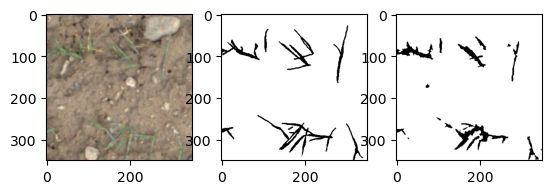

In [458]:
showResult(0)

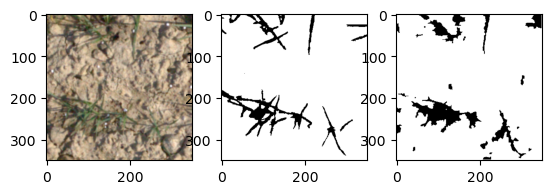

In [459]:
showResult(1)

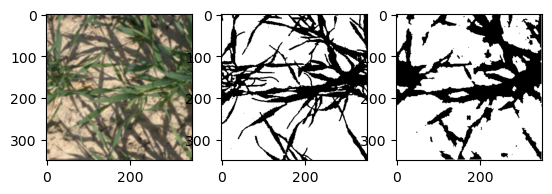

In [460]:
showResult(8)